# Stein Variational Gradient Descent

Particle-based variational inference.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.models import MLP
from deepuq.methods.svgd import SVGDWrapper

## Generate Data

In [2]:
np.random.seed(42)
x_train = np.random.uniform(-3, 3, 100).astype(np.float32)
y_train = (np.sin(x_train) + np.random.normal(0, 0.1, 100)).astype(np.float32)
x_test = np.linspace(-5, 5, 200).astype(np.float32)

x_train_t = torch.from_numpy(x_train).unsqueeze(-1)
y_train_t = torch.from_numpy(y_train).unsqueeze(-1)
x_test_t = torch.from_numpy(x_test).unsqueeze(-1)

train_dataset = torch.utils.data.TensorDataset(x_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

## Train SVGD Particles

In [3]:
# Create SVGD wrapper with 10 particles
svgd = SVGDWrapper(
    model_fn=lambda: MLP(1, [32, 32], 1),
    n_particles=10
)

# Train
svgd.fit(train_loader, n_epochs=200)

## Predict with Uncertainty

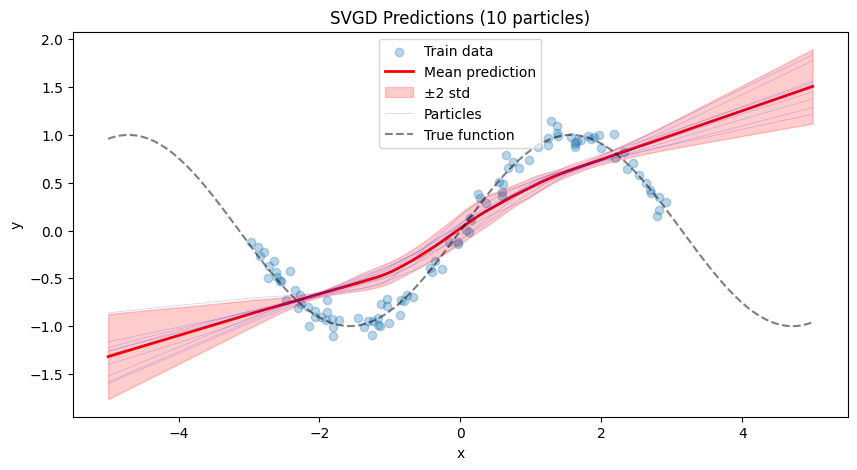

In [4]:
# Get predictions with uncertainty (returns UQResult)
result = svgd.predict_uq(x_test_t)
mean = result.mean.numpy().squeeze()
std = result.epistemic_var.sqrt().numpy().squeeze()

# Get individual particle predictions
particle_preds = []
for particle in svgd.particles:
    with torch.no_grad():
        particle_preds.append(particle(x_test_t).numpy().squeeze())

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, alpha=0.3, label="Train data")
plt.plot(x_test, mean, "r-", linewidth=2, label="Mean prediction")
plt.fill_between(x_test, mean - 2*std, mean + 2*std, alpha=0.2, color="red", label="\u00b12 std")

# Plot individual particle predictions
for i, pred in enumerate(particle_preds):
    plt.plot(x_test, pred, alpha=0.2, color="blue", linewidth=0.5,
             label="Particles" if i == 0 else None)

plt.plot(x_test, np.sin(x_test), "k--", alpha=0.5, label="True function")
plt.legend()
plt.title("SVGD Predictions (10 particles)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()